<a href="https://colab.research.google.com/github/naveenbharti973/Diabetes-Prediction-Using-KNN_ALGO/blob/main/ANN_Prediction.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:

!pip install -q scikit-learn matplotlib seaborn pandas tensorflow
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import confusion_matrix, classification_report, accuracy_score

from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.naive_bayes import GaussianNB

import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense


In [2]:
url = 'https://raw.githubusercontent.com/jbrownlee/Datasets/master/pima-indians-diabetes.data.csv'
columns = ['Pregnancies','Glucose','BloodPressure','SkinThickness','Insulin','BMI','DiabetesPedigreeFunction','Age','Outcome']
data = pd.read_csv(url, names=columns)

print(data.head())
print(data.describe())
print(data['Outcome'].value_counts())


   Pregnancies  Glucose  BloodPressure  SkinThickness  Insulin   BMI  \
0            6      148             72             35        0  33.6   
1            1       85             66             29        0  26.6   
2            8      183             64              0        0  23.3   
3            1       89             66             23       94  28.1   
4            0      137             40             35      168  43.1   

   DiabetesPedigreeFunction  Age  Outcome  
0                     0.627   50        1  
1                     0.351   31        0  
2                     0.672   32        1  
3                     0.167   21        0  
4                     2.288   33        1  
       Pregnancies     Glucose  BloodPressure  SkinThickness     Insulin  \
count   768.000000  768.000000     768.000000     768.000000  768.000000   
mean      3.845052  120.894531      69.105469      20.536458   79.799479   
std       3.369578   31.972618      19.355807      15.952218  115.244002   

In [3]:
print(data.isnull().sum())

X = data.drop('Outcome', axis=1)
y = data['Outcome']

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size=0.2, random_state=42)
results = []


Pregnancies                 0
Glucose                     0
BloodPressure               0
SkinThickness               0
Insulin                     0
BMI                         0
DiabetesPedigreeFunction    0
Age                         0
Outcome                     0
dtype: int64


In [4]:
def evaluate_model(model, X_train, y_train, X_test, y_test, model_name):
    y_train_pred = model.predict(X_train)
    train_acc = accuracy_score(y_train, y_train_pred)

    y_test_pred = model.predict(X_test)
    test_acc = accuracy_score(y_test, y_test_pred)

    print(f"\n{model_name} - Training Accuracy: {train_acc:.4f}, Testing Accuracy: {test_acc:.4f}")
    print(classification_report(y_test, y_test_pred))

    cm = confusion_matrix(y_test, y_test_pred)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
    plt.title(f"{model_name} - Confusion Matrix")
    plt.xlabel("Predicted")
    plt.ylabel("Actual")
    plt.show()

    results.append({
        'Model': model_name,
        'Training Accuracy': round(train_acc, 4),
        'Testing Accuracy': round(test_acc, 4)
    })



SVM - Training Accuracy: 0.8290, Testing Accuracy: 0.7273
              precision    recall  f1-score   support

           0       0.77      0.82      0.79        99
           1       0.63      0.56      0.60        55

    accuracy                           0.73       154
   macro avg       0.70      0.69      0.70       154
weighted avg       0.72      0.73      0.72       154



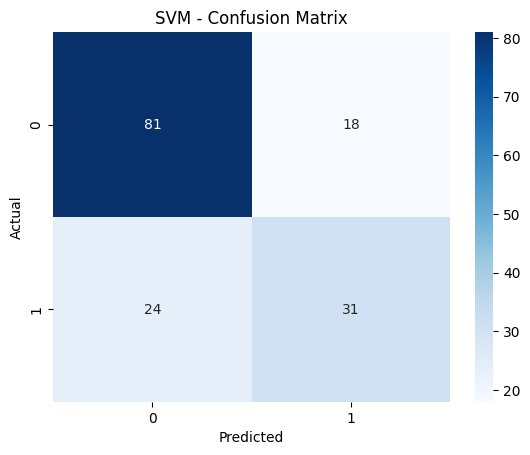

In [5]:
svm = SVC()
svm.fit(X_train, y_train)
evaluate_model(svm, X_train, y_train, X_test, y_test, "SVM")



KNN - Training Accuracy: 0.8208, Testing Accuracy: 0.6883
              precision    recall  f1-score   support

           0       0.74      0.80      0.77        99
           1       0.57      0.49      0.53        55

    accuracy                           0.69       154
   macro avg       0.66      0.64      0.65       154
weighted avg       0.68      0.69      0.68       154



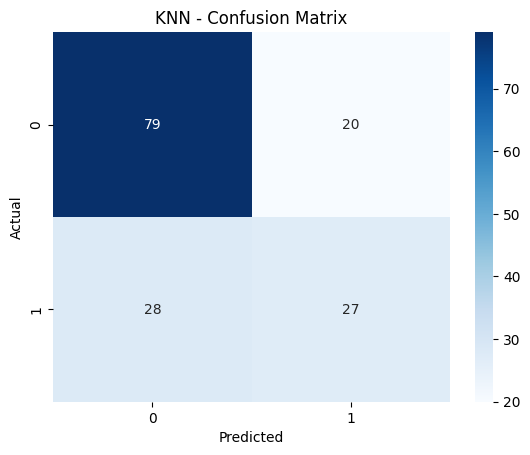

In [6]:
knn = KNeighborsClassifier(n_neighbors=5)
knn.fit(X_train, y_train)
evaluate_model(knn, X_train, y_train, X_test, y_test, "KNN")



Naive Bayes - Training Accuracy: 0.7524, Testing Accuracy: 0.7662
              precision    recall  f1-score   support

           0       0.83      0.80      0.81        99
           1       0.66      0.71      0.68        55

    accuracy                           0.77       154
   macro avg       0.75      0.75      0.75       154
weighted avg       0.77      0.77      0.77       154



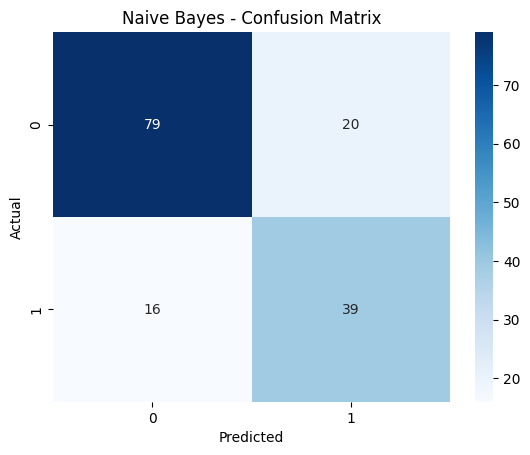

In [7]:
nb = GaussianNB()
nb.fit(X_train, y_train)
evaluate_model(nb, X_train, y_train, X_test, y_test, "Naive Bayes")


/usr/local/lib/python3.11/dist-packages/keras/src/layers/core/dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step 

ANN - Training Accuracy: 0.8176, Testing Accuracy: 0.7857
              precision    recall  f1-score   support

           0       0.84      0.83      0.83        99
           1       0.70      0.71      0.70        55

    accuracy                           0.79       154
   macro avg       0.77      0.77      0.77       154
weighted avg       0.79      0.79      0.79       154



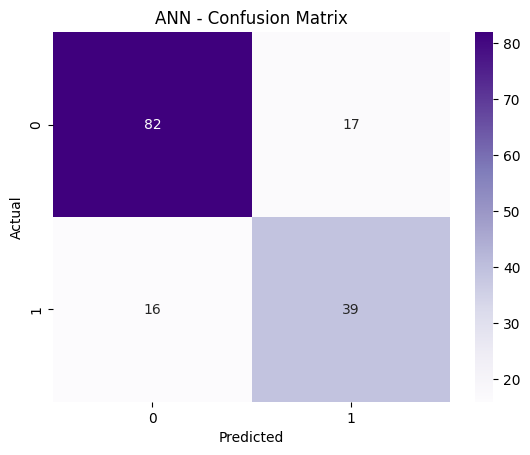

In [8]:
ann = Sequential([
    Dense(16, input_shape=(X_train.shape[1],), activation='relu'),
    Dense(8, activation='relu'),
    Dense(1, activation='sigmoid')
])

ann.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])
ann.fit(X_train, y_train, epochs=100, batch_size=10, verbose=0)

y_train_ann = (ann.predict(X_train) > 0.5).astype("int32")
train_acc_ann = accuracy_score(y_train, y_train_ann)

y_test_ann = (ann.predict(X_test) > 0.5).astype("int32")
test_acc_ann = accuracy_score(y_test, y_test_ann)

print(f"\nANN - Training Accuracy: {train_acc_ann:.4f}, Testing Accuracy: {test_acc_ann:.4f}")
print(classification_report(y_test, y_test_ann))

cm_ann = confusion_matrix(y_test, y_test_ann)
sns.heatmap(cm_ann, annot=True, fmt='d', cmap='Purples')
plt.title("ANN - Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

results.append({
    'Model': 'ANN',
    'Training Accuracy': round(train_acc_ann, 4),
    'Testing Accuracy': round(test_acc_ann, 4)
})


Model Comparison Table:


,Model,Training Accuracy,Testing Accuracy
0,SVM,0.8290,0.7273
1,KNN,0.8208,0.6883
2,Naive Bayes,0.7524,0.7662
3,ANN,0.8176,0.7857


<ipython-input-9-fa1e01f9ed0f>:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=models, y=accuracies, palette='pastel')


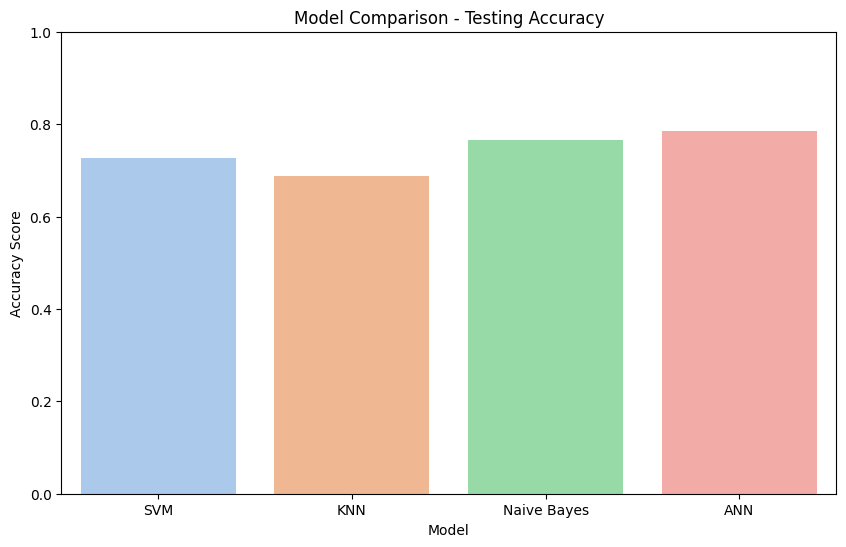


🏆 Best Model Based on Testing Accuracy:
  Model Training Accuracy Testing Accuracy
0   ANN            0.8176           0.7857

🎉 ANN achieved the highest accuracy among all models!


In [9]:
results_df = pd.DataFrame(results)
print("Model Comparison Table:")
display(results_df)

# Plot accuracy comparison
models = results_df['Model']
accuracies = results_df['Testing Accuracy']

plt.figure(figsize=(10,6))
sns.barplot(x=models, y=accuracies, palette='pastel')
plt.title("Model Comparison - Testing Accuracy")
plt.ylabel("Accuracy Score")
plt.ylim(0, 1)
plt.show()

# Show best model
sorted_df = results_df.sort_values(by='Testing Accuracy', ascending=False).reset_index(drop=True)
best_model = sorted_df.iloc[0]
print("\n🏆 Best Model Based on Testing Accuracy:")
print(best_model.to_frame().T)

if best_model['Model'] == 'ANN':
    print("\n🎉 ANN achieved the highest accuracy among all models!")
else:
    print(f"\nANN did NOT achieve the highest accuracy. Best model: {best_model['Model']}")
